In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.info())
print(df.describe())

   Order Date  Product     Category Region Customer Type  Quantity  \
0  2025-10-16    Mouse  Electronics  South        Retail         1   
1  2025-11-23   Bottle  Accessories  North        Retail         3   
2  2024-08-11    Chair    Furniture  South     Wholesale        17   
3  2024-08-13  Monitor  Electronics  North        Retail        19   
4  2025-12-15  Printer  Electronics   East        Retail        11   

   Unit Price  Discount   Revenue    Profit  
0         800        10     720.0    221.23  
1         350        20     840.0    129.59  
2        4500        20   61200.0  18516.00  
3       15000        10  256500.0  30543.70  
4       12000        10  118800.0  40043.01  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order Date     1000 non-null   object 
 1   Product        1000 non-null   object 
 2   Category       1

In [5]:
# Missing values
print(df.isnull().sum())

# Duplicate values
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Order Date       0
Product          0
Category         0
Region           0
Customer Type    0
Quantity         0
Unit Price       0
Discount         0
Revenue          0
Profit           0
dtype: int64
0


In [6]:
X = df[['Quantity', 'Unit Price', 'Discount']]
y = df['Revenue']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.744303984762547


In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: 0.998496930483454


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.shape)
print(df.info())

   Order Date  Product     Category Region Customer Type  Quantity  \
0  2025-10-16    Mouse  Electronics  South        Retail         1   
1  2025-11-23   Bottle  Accessories  North        Retail         3   
2  2024-08-11    Chair    Furniture  South     Wholesale        17   
3  2024-08-13  Monitor  Electronics  North        Retail        19   
4  2025-12-15  Printer  Electronics   East        Retail        11   

   Unit Price  Discount   Revenue    Profit  
0         800        10     720.0    221.23  
1         350        20     840.0    129.59  
2        4500        20   61200.0  18516.00  
3       15000        10  256500.0  30543.70  
4       12000        10  118800.0  40043.01  
(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order Date     1000 non-null   object 
 1   Product        1000 non-null   object 
 2   Categ

In [11]:
print(df.isnull().sum())

Order Date       0
Product          0
Category         0
Region           0
Customer Type    0
Quantity         0
Unit Price       0
Discount         0
Revenue          0
Profit           0
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
print(df.describe())

          Quantity   Unit Price     Discount       Revenue         Profit
count  1000.000000   1000.00000  1000.000000  1.000000e+03    1000.000000
mean     10.612000  10277.86000    10.280000  1.001719e+05   22474.579490
std       5.793014  16343.95374     7.132494  1.887624e+05   50742.223683
min       1.000000    120.00000     0.000000  9.600000e+01  -34788.360000
25%       6.000000    800.00000     5.000000  5.302500e+03     715.922500
50%      10.000000   4500.00000    10.000000  2.400000e+04    4307.010000
75%      16.000000  12000.00000    15.000000  1.000125e+05   21818.997500
max      20.000000  55000.00000    20.000000  1.100000e+06  465925.760000


In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [16]:
monthly_revenue = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Revenue"].sum()

print(monthly_revenue)

Order Date
2024-01    2492615.0
2024-02    3407804.5
2024-03    5358288.0
2024-04    6131821.0
2024-05    6705358.5
2024-06    5609025.0
2024-07    4096303.5
2024-08    4220558.0
2024-09    2567007.0
2024-10    4295726.0
2024-11    3583985.5
2024-12    2878074.0
2025-01    4734531.0
2025-02    5862570.0
2025-03    3144597.5
2025-04    3580892.0
2025-05    3288907.0
2025-06    3235692.0
2025-07    6294239.5
2025-08    6602904.5
2025-09    4204307.0
2025-10    2333930.0
2025-11    2466820.5
2025-12    3075989.0
Freq: M, Name: Revenue, dtype: float64


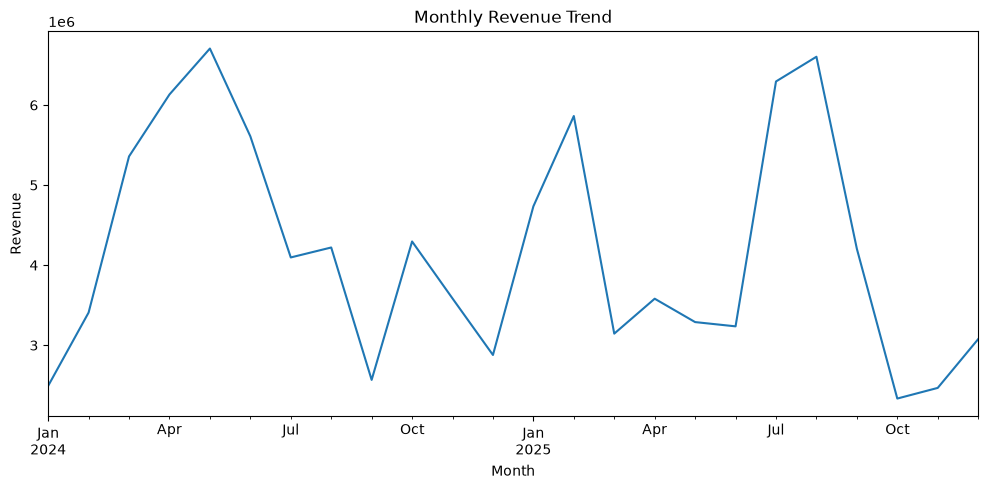

In [17]:
monthly_revenue.plot(kind="line", figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [18]:
category_revenue = df.groupby("Category")["Revenue"].sum()

print(category_revenue)

Category
Accessories     1949405.0
Electronics    88127335.0
Furniture       9979100.0
Stationery       116106.0
Name: Revenue, dtype: float64


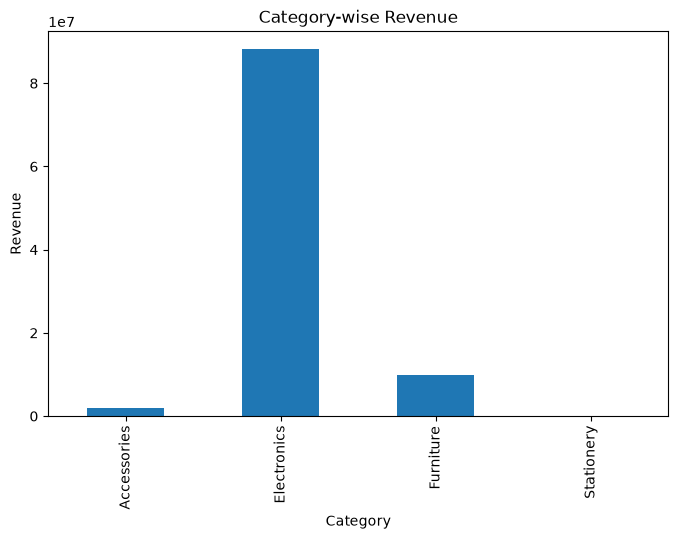

In [19]:
category_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

In [20]:
region_revenue = df.groupby("Region")["Revenue"].sum()

print(region_revenue)

Region
East     21494634.5
North    29131728.0
South    23904148.0
West     25641435.5
Name: Revenue, dtype: float64


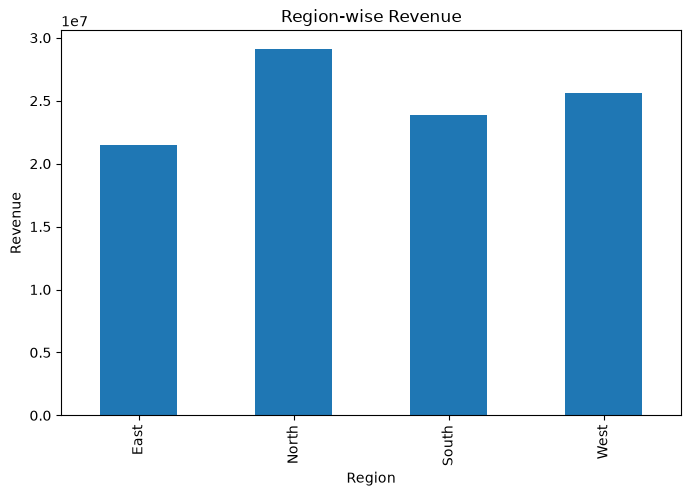

In [21]:
region_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

In [22]:
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product
Laptop      58671250.0
Monitor     15118500.0
Printer     12191400.0
Table        5185250.0
Chair        4793850.0
Bag          1642770.0
Keyboard     1378425.0
Mouse         767760.0
Bottle        306635.0
Notebook      116106.0
Name: Revenue, dtype: float64


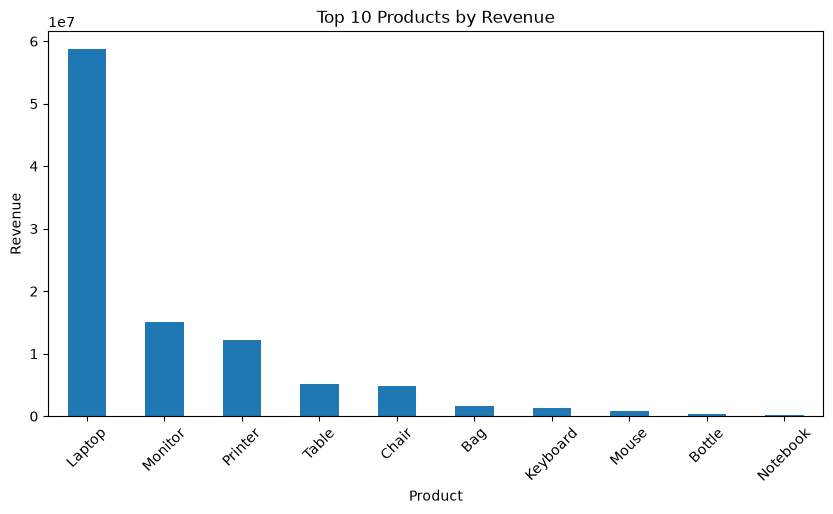

In [23]:
top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Feature Engineering

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["DayOfWeek"] = df["Order Date"].dt.dayofweek

print(df.head())

  Order Date  Product     Category Region Customer Type  Quantity  Unit Price  \
0 2025-10-16    Mouse  Electronics  South        Retail         1         800   
1 2025-11-23   Bottle  Accessories  North        Retail         3         350   
2 2024-08-11    Chair    Furniture  South     Wholesale        17        4500   
3 2024-08-13  Monitor  Electronics  North        Retail        19       15000   
4 2025-12-15  Printer  Electronics   East        Retail        11       12000   

   Discount   Revenue    Profit  Year  Month  Day  DayOfWeek  
0        10     720.0    221.23  2025     10   16          3  
1        20     840.0    129.59  2025     11   23          6  
2        20   61200.0  18516.00  2024      8   11          6  
3        10  256500.0  30543.70  2024      8   13          1  
4        10  118800.0  40043.01  2025     12   15          0  


In [25]:
print(df[["Order Date", "Year", "Month", "Day", "DayOfWeek"]].head(10))

  Order Date  Year  Month  Day  DayOfWeek
0 2025-10-16  2025     10   16          3
1 2025-11-23  2025     11   23          6
2 2024-08-11  2024      8   11          6
3 2024-08-13  2024      8   13          1
4 2025-12-15  2025     12   15          0
5 2024-04-04  2024      4    4          3
6 2025-04-15  2025      4   15          1
7 2025-08-14  2025      8   14          3
8 2024-08-26  2024      8   26          0
9 2025-01-14  2025      1   14          1


In [26]:
X = df[[
    "Quantity",
    "Unit Price",
    "Discount",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]]

y = df["Revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 7)
y shape: (1000,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 7)
Testing data: (200, 7)


In [28]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [29]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:10])

[516377.15545712  13473.27271236 -51584.49999282  94206.18493343
 140517.95524563  -2139.55801473  91733.60589394 -15580.25957339
  97876.76540805  57206.21374793]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
--------------------------
MAE : 48309.86975800851
MSE : 5927992975.33428
RMSE: 76993.46060110742
R2 Score: 0.7435356744688513


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [32]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[381397.5    4125.1     453.12  82712.   136599.    16136.    68424.
    909.48  14468.8    4662.35]


In [33]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
---------------------
MAE : 4167.450225
MSE : 104624125.14252388
RMSE: 10228.593507541684
R2 Score: 0.9954736188452634


In [35]:
from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


In [36]:
# Prepare data for Prophet

prophet_df = df[["Order Date", "Revenue"]].copy()

prophet_df.columns = ["ds", "y"]

# Monthly revenue
prophet_df = (
    prophet_df
    .set_index("ds")
    .resample("MS")["y"]
    .sum()
    .reset_index()
)

print(prophet_df.head())
print(prophet_df.tail())

          ds          y
0 2024-01-01  2492615.0
1 2024-02-01  3407804.5
2 2024-03-01  5358288.0
3 2024-04-01  6131821.0
4 2024-05-01  6705358.5
           ds          y
19 2025-08-01  6602904.5
20 2025-09-01  4204307.0
21 2025-10-01  2333930.0
22 2025-11-01  2466820.5
23 2025-12-01  3075989.0


In [37]:
prophet_model = Prophet()

prophet_model.fit(prophet_df)

print("Prophet model trained successfully!")


10:40:07 - cmdstanpy - INFO - Chain [1] start processing
10:40:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [38]:
future = prophet_model.make_future_dataframe(
    periods=6,
    freq="MS"
)

forecast = prophet_model.predict(future)

print(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)
)

           ds          yhat    yhat_lower    yhat_upper
24 2026-01-01  3.656293e+06  1.941369e+06  5.418111e+06
25 2026-02-01  3.613903e+06  1.725385e+06  5.234943e+06
26 2026-03-01  3.575615e+06  1.748334e+06  5.214071e+06
27 2026-04-01  3.533224e+06  1.754664e+06  5.424076e+06
28 2026-05-01  3.492201e+06  1.666199e+06  5.227766e+06
29 2026-06-01  3.449811e+06  1.821815e+06  5.071556e+06


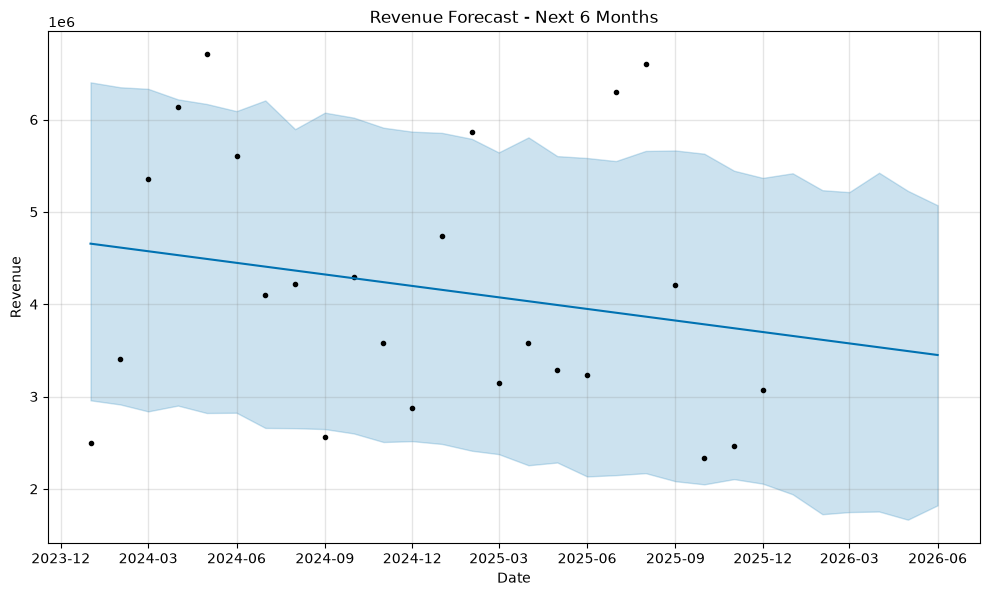

In [39]:
fig = prophet_model.plot(forecast)

plt.title("Revenue Forecast - Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [40]:
future_forecast = forecast[
    forecast["ds"] > prophet_df["ds"].max()
][["ds", "yhat", "yhat_lower", "yhat_upper"]]

print(future_forecast)

           ds          yhat    yhat_lower    yhat_upper
24 2026-01-01  3.656293e+06  1.941369e+06  5.418111e+06
25 2026-02-01  3.613903e+06  1.725385e+06  5.234943e+06
26 2026-03-01  3.575615e+06  1.748334e+06  5.214071e+06
27 2026-04-01  3.533224e+06  1.754664e+06  5.424076e+06
28 2026-05-01  3.492201e+06  1.666199e+06  5.227766e+06
29 2026-06-01  3.449811e+06  1.821815e+06  5.071556e+06


In [41]:
future_forecast["yhat"] = future_forecast["yhat"].round(2)
future_forecast["yhat_lower"] = future_forecast["yhat_lower"].round(2)
future_forecast["yhat_upper"] = future_forecast["yhat_upper"].round(2)

print(future_forecast)

           ds        yhat  yhat_lower  yhat_upper
24 2026-01-01  3656292.87  1941368.99  5418110.75
25 2026-02-01  3613902.54  1725384.97  5234942.69
26 2026-03-01  3575614.51  1748334.47  5214070.93
27 2026-04-01  3533224.19  1754664.47  5424076.05
28 2026-05-01  3492201.29  1666199.49  5227765.88
29 2026-06-01  3449810.97  1821815.36  5071556.49


In [42]:
future_forecast.to_csv(
    "revenue_forecast.csv",
    index=False
)

print("Forecast CSV saved successfully!")

Forecast CSV saved successfully!


In [43]:
print(future_forecast)

           ds        yhat  yhat_lower  yhat_upper
24 2026-01-01  3656292.87  1941368.99  5418110.75
25 2026-02-01  3613902.54  1725384.97  5234942.69
26 2026-03-01  3575614.51  1748334.47  5214070.93
27 2026-04-01  3533224.19  1754664.47  5424076.05
28 2026-05-01  3492201.29  1666199.49  5227765.88
29 2026-06-01  3449810.97  1821815.36  5071556.49
